In [1]:
# Cell 1: Colab-ready setup, all imports, environment check, and optional Google Drive mounting
!pip -q install "stable-baselines3[extra]" "gymnasium[atari,accept-rom-license]" ale-py

import csv
import datetime
import gc
import os
import shutil
import time
from pathlib import Path
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import pandas as pd
import gymnasium as gym
import ale_py  # noqa: F401
from gymnasium.wrappers import RecordVideo
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

_ = ale_py  # keep explicit reference so static analyzers do not flag import
_ = os  # kept for optional path/env diagnostics in Colab

COLAB_FILES = None
COLAB_DRIVE = None
try:
    from google.colab import drive as _drive, files as _files  # type: ignore
    COLAB_DRIVE = _drive
    COLAB_FILES = _files
except Exception:
    pass

ENV_ID = "ALE/Tennis-v5"
MEMBER = "raissa"

# Local artifact structure
BASE_DIR = Path("results") / MEMBER
MODEL_DIR = BASE_DIR / "models"
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"
VIDEO_DIR = BASE_DIR / "videos"

for p in [MODEL_DIR, LOG_DIR, TABLE_DIR, VIDEO_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Optional Google Drive mount (works on Colab)
DRIVE_MOUNTED = False
DRIVE_EXPORT_DIR = None
if COLAB_DRIVE is not None:
    try:
        COLAB_DRIVE.mount('/content/drive')
        DRIVE_MOUNTED = True
        DRIVE_EXPORT_DIR = Path('/content/drive/MyDrive/Tenis_dqn_agent') / MEMBER
        DRIVE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
        print(f"Google Drive mounted. Export path: {DRIVE_EXPORT_DIR}")
    except Exception:
        print("Google Drive mount failed.")
else:
    print("Google Drive not mounted (this is fine outside Colab).")

# Quick environment sanity check for CNN pipeline
test_env = make_atari_env(ENV_ID, n_envs=1, seed=42)
test_env = VecFrameStack(test_env, n_stack=4)
test_env.close()
print(f"Environment ready: {ENV_ID}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 5.7 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Google Drive mount failed.
Environment ready: ALE/Tennis-v5


In [2]:
# Cell 2: Reusable training utilities (supports both CnnPolicy and MlpPolicy)
class EpisodeCSVLogger(BaseCallback):
    def __init__(self, run_name: str, csv_path: str, log_path: str, verbose: int = 1):
        super().__init__(verbose)
        self.run_name = run_name
        self.csv_path = csv_path
        self.log_path = log_path
        self.rows = []

    def _on_training_start(self) -> None:
        Path(self.csv_path).parent.mkdir(parents=True, exist_ok=True)
        Path(self.log_path).parent.mkdir(parents=True, exist_ok=True)
        with open(self.log_path, "a", encoding="utf-8") as f:
            f.write(f"[{self._ts()}] [RUN {self.run_name}] logging started\n")

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            if "episode" in info:
                ep = info["episode"]
                ep_len = ep.get("l")
                ep_rew = ep.get("r")
                self.rows.append((self.num_timesteps, ep_len, ep_rew))
                eps = getattr(self.model, "exploration_rate", None)
                line = f"[{self._ts()}] [RUN {self.run_name}] t={self.num_timesteps} | episode_end len={ep_len} reward={ep_rew:.2f}"
                if eps is not None:
                    line += f" | eps={eps:.4f}"
                print(line, flush=True)
                with open(self.log_path, "a", encoding="utf-8") as f:
                    f.write(line + "\n")
        return True

    def _on_training_end(self) -> None:
        with open(self.csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["timestep", "ep_length", "ep_reward"])
            writer.writerows(self.rows)
        with open(self.log_path, "a", encoding="utf-8") as f:
            f.write(f"[{self._ts()}] [RUN {self.run_name}] episode CSV saved -> {self.csv_path}\n")
        print(f"Saved episode CSV to {self.csv_path}")

    @staticmethod
    def _ts() -> str:
        return datetime.datetime.now().strftime("%H:%M:%S")


def make_env(policy: str, seed: int):
    if policy == "CnnPolicy":
        env = make_atari_env(ENV_ID, n_envs=1, seed=seed)
        env = VecFrameStack(env, n_stack=4)
        return env

    # MLP uses RAM observations from ALE/Tennis-ram-v5
    ram_env_id = ENV_ID.replace("-v5", "-ram-v5")
    raw_env = gym.make(ram_env_id)
    raw_env = Monitor(raw_env)
    env = DummyVecEnv([lambda: raw_env])
    return env


def train_experiment(
    name: str,
    policy: str,
    hp: Dict,
    total_timesteps: int = 300_000,
    seed: int = 42,
    eval_episodes: int = 3,
    device: str = "auto",
) -> Tuple[Dict, DQN]:
    csv_log = str(LOG_DIR / f"{name}_training_metrics.csv")
    run_log = str(LOG_DIR / f"run_{name}.log")
    callback = EpisodeCSVLogger(run_name=name, csv_path=csv_log, log_path=run_log, verbose=1)

    env = make_env(policy=policy, seed=seed)
    eval_env = make_env(policy=policy, seed=seed + 100)

    model = DQN(
        policy,
        env,
        seed=seed,
        device=device,
        tensorboard_log=str(LOG_DIR / "tensorboard" / name),
        optimize_memory_usage=False,
        **hp,
    )

    start_msg = f"[{datetime.datetime.now().strftime('%H:%M:%S')}] [RUN {name}] START {policy} training {total_timesteps} steps | hp={hp}"
    print(start_msg, flush=True)
    with open(run_log, "a", encoding="utf-8") as f:
        f.write(start_msg + "\n")

    t0 = time.time()
    model.learn(total_timesteps=total_timesteps, callback=callback, progress_bar=True)
    minutes = (time.time() - t0) / 60.0

    mean_r, std_r = evaluate_policy(model, eval_env, n_eval_episodes=eval_episodes, deterministic=True)

    env.close()
    eval_env.close()

    end_msg = f"[{datetime.datetime.now().strftime('%H:%M:%S')}] [RUN {name}] END mean_reward={mean_r:.2f} +/- {std_r:.2f} | train_minutes={minutes:.2f}"
    print(end_msg, flush=True)
    with open(run_log, "a", encoding="utf-8") as f:
        f.write(end_msg + "\n")

    metrics = {
        "name": name,
        "policy": policy,
        "mean_reward": float(mean_r),
        "std_reward": float(std_r),
        "train_minutes": float(minutes),
        "learning_rate": hp["learning_rate"],
        "gamma": hp["gamma"],
        "batch_size": hp["batch_size"],
        "exploration_initial_eps": hp["exploration_initial_eps"],
        "exploration_final_eps": hp["exploration_final_eps"],
        "exploration_fraction": hp["exploration_fraction"],
    }
    return metrics, model


print("Training utilities ready.")

Training utilities ready.


In [3]:
# Cell 3: Define 10 Raissa-specific hyperparameter experiments (unique combinations)
# Includes both CnnPolicy and MlpPolicy for architecture comparison.

experiments = [
    {
        "name": "raissa-exp01-cnn-baseline",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.99, batch_size=32, buffer_size=100_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp02-cnn-low-lr",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=5e-5, gamma=0.99, batch_size=32, buffer_size=100_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp03-cnn-higher-lr",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=2.5e-4, gamma=0.99, batch_size=32, buffer_size=100_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp04-cnn-gamma-097",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.97, batch_size=32, buffer_size=100_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp05-cnn-batch-64",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.99, batch_size=64, buffer_size=120_000, train_freq=4, gradient_steps=1, target_update_interval=12_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp06-cnn-batch-128",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.99, batch_size=128, buffer_size=150_000, train_freq=4, gradient_steps=1, target_update_interval=15_000, exploration_fraction=0.12, exploration_initial_eps=1.0, exploration_final_eps=0.02, verbose=0),
    },
    {
        "name": "raissa-exp07-cnn-slow-epsilon-decay",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.99, batch_size=64, buffer_size=120_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.25, exploration_initial_eps=1.0, exploration_final_eps=0.05, verbose=0),
    },
    {
        "name": "raissa-exp08-cnn-fast-epsilon-decay",
        "policy": "CnnPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.99, batch_size=64, buffer_size=120_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.05, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp09-mlp-baseline-ram",
        "policy": "MlpPolicy",
        "hp": dict(learning_rate=1e-4, gamma=0.99, batch_size=64, buffer_size=80_000, train_freq=4, gradient_steps=1, target_update_interval=10_000, exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.01, verbose=0),
    },
    {
        "name": "raissa-exp10-mlp-alt",
        "policy": "MlpPolicy",
        "hp": dict(learning_rate=2e-4, gamma=0.98, batch_size=128, buffer_size=100_000, train_freq=4, gradient_steps=1, target_update_interval=8_000, exploration_fraction=0.15, exploration_initial_eps=1.0, exploration_final_eps=0.02, verbose=0),
    },
]

print(f"Prepared {len(experiments)} experiment configs.")
pd.DataFrame(
    [
        {
            "name": e["name"],
            "policy": e["policy"],
            "learning_rate": e["hp"]["learning_rate"],
            "gamma": e["hp"]["gamma"],
            "batch_size": e["hp"]["batch_size"],
            "eps_start": e["hp"]["exploration_initial_eps"],
            "eps_end": e["hp"]["exploration_final_eps"],
            "eps_frac": e["hp"]["exploration_fraction"],
        }
        for e in experiments
    ]
)

Prepared 10 experiment configs.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,name,policy,learning_rate,gamma,batch_size,eps_start,eps_end,eps_frac
0,raissa-exp01-cnn-baseline,CnnPolicy,0.00010,0.99,32,1.0,0.01,0.10
1,raissa-exp02-cnn-low-lr,CnnPolicy,0.00005,0.99,32,1.0,0.01,0.10
2,raissa-exp03-cnn-higher-lr,CnnPolicy,0.00025,0.99,32,1.0,0.01,0.10
3,raissa-exp04-cnn-gamma-097,CnnPolicy,0.00010,0.97,32,1.0,0.01,0.10
4,raissa-exp05-cnn-batch-64,CnnPolicy,0.00010,0.99,64,1.0,0.01,0.10
5,raissa-exp06-cnn-batch-128,CnnPolicy,0.00010,0.99,128,1.0,0.02,0.12
6,raissa-exp07-cnn-slow-epsilon-decay,CnnPolicy,0.00010,0.99,64,1.0,0.05,0.25
7,raissa-exp08-cnn-fast-epsilon-decay,CnnPolicy,0.00010,0.99,64,1.0,0.01,0.05
8,raissa-exp09-mlp-baseline-ram,MlpPolicy,0.00010,0.99,64,1.0,0.01,0.10
9,raissa-exp10-mlp-alt,MlpPolicy,0.00020,0.98,128,1.0,0.02,0.15


In [4]:
# Cell 4: Run all experiments, save each model, keep best model, and build results table
TOTAL_TIMESTEPS = 50_000
SEED = 42
EVAL_EPISODES = 3
DEVICE = "auto"

BEST_MODEL_PATH = MODEL_DIR / "best_dqn_tennis.zip"
ASSIGNMENT_MODEL_PATH = MODEL_DIR / "dqn_model.zip"

results = []
best_record = None
best_mean_reward = None

for exp in experiments:
    name = exp["name"]
    policy = exp["policy"]
    hp = exp["hp"]

    print(f"\n===== Running {name} ({policy}) =====")
    try:
        metrics, model = train_experiment(
            name=name,
            policy=policy,
            hp=hp,
            total_timesteps=TOTAL_TIMESTEPS,
            seed=SEED,
            eval_episodes=EVAL_EPISODES,
            device=DEVICE,
        )

        model_path = MODEL_DIR / f"{name}.zip"
        model.save(str(model_path))
        print(f"[SAVE] {name} -> {model_path}")

        metrics["model_path"] = str(model_path)
        results.append(metrics)

        if (best_mean_reward is None) or (metrics["mean_reward"] > best_mean_reward):
            best_mean_reward = metrics["mean_reward"]
            best_record = dict(metrics)
            shutil.copy(str(model_path), str(BEST_MODEL_PATH))
            shutil.copy(str(model_path), str(ASSIGNMENT_MODEL_PATH))
            print(f"[BEST] Updated -> {BEST_MODEL_PATH}")
            print(f"[ASSIGNMENT] Updated -> {ASSIGNMENT_MODEL_PATH}")

    except Exception as e:
        print(f"[ERROR] {name} failed: {e}")

    finally:
        try:
            del model
        except Exception:
            pass
        gc.collect()

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values("mean_reward", ascending=False).reset_index(drop=True)
    print("\nTop result:")
    display(results_df.head(1))
else:
    print("No successful runs yet.")

results_df

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 49,988/50,000  [ 0:06:18 < 0:00:01 , 131 it/s ]

Saved episode CSV to results/raissa/logs/raissa-exp08-cnn-fast-epsilon-decay_training_metrics.csv

[14:35:33] [RUN raissa-exp08-cnn-fast-epsilon-decay] END mean_reward=-9.67 +/- 0.94 | train_minutes=6.32
[SAVE] raissa-exp08-cnn-fast-epsilon-decay -> results/raissa/models/raissa-exp08-cnn-fast-epsilon-decay.zip

===== Running raissa-exp09-mlp-baseline-ram (MlpPolicy) =====
[ERROR] raissa-exp09-mlp-baseline-ram failed: Environment `Tennis-ram` doesn't exist in namespace ALE. Did you mean: `Tennis`?

===== Running raissa-exp10-mlp-alt (MlpPolicy) =====
[ERROR] raissa-exp10-mlp-alt failed: Environment `Tennis-ram` doesn't exist in namespace ALE. Did you mean: `Tennis`?

Top result:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,name,policy,mean_reward,std_reward,train_minutes,learning_rate,gamma,batch_size,exploration_initial_eps,exploration_final_eps,exploration_fraction,model_path
0,raissa-exp01-cnn-baseline,CnnPolicy,-1.0,0.0,6.004621,0.0001,0.99,32,1.0,0.01,0.1,results/raissa/models/raissa-exp01-cnn-baselin...


,name,policy,mean_reward,std_reward,train_minutes,learning_rate,gamma,batch_size,exploration_initial_eps,exploration_final_eps,exploration_fraction,model_path
0,raissa-exp01-cnn-baseline,CnnPolicy,-1.000000,0.000000,6.004621,0.00010,0.99,32,1.0,0.01,0.10,results/raissa/models/raissa-exp01-cnn-baselin...
1,raissa-exp02-cnn-low-lr,CnnPolicy,-1.000000,0.000000,5.902203,0.00005,0.99,32,1.0,0.01,0.10,results/raissa/models/raissa-exp02-cnn-low-lr.zip
2,raissa-exp03-cnn-higher-lr,CnnPolicy,-1.000000,0.000000,5.966845,0.00025,0.99,32,1.0,0.01,0.10,results/raissa/models/raissa-exp03-cnn-higher-...
3,raissa-exp04-cnn-gamma-097,CnnPolicy,-1.000000,0.000000,5.969977,0.00010,0.97,32,1.0,0.01,0.10,results/raissa/models/raissa-exp04-cnn-gamma-0...
4,raissa-exp07-cnn-slow-epsilon-decay,CnnPolicy,-1.000000,0.000000,6.201877,0.00010,0.99,64,1.0,0.05,0.25,results/raissa/models/raissa-exp07-cnn-slow-ep...
5,raissa-exp05-cnn-batch-64,CnnPolicy,-2.000000,0.816497,6.300254,0.00010,0.99,64,1.0,0.01,0.10,results/raissa/models/raissa-exp05-cnn-batch-6...
6,raissa-exp08-cnn-fast-epsilon-decay,CnnPolicy,-9.666667,0.942809,6.319442,0.00010,0.99,64,1.0,0.01,0.05,results/raissa/models/raissa-exp08-cnn-fast-ep...
7,raissa-exp06-cnn-batch-128,CnnPolicy,-13.333333,3.858612,7.718636,0.00010,0.99,128,1.0,0.02,0.12,results/raissa/models/raissa-exp06-cnn-batch-1...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Cell 5: Save results table locally and as markdown-ready table for README
RESULTS_CSV = TABLE_DIR / "raissa_hyperparameter_results.csv"
RESULTS_MD = TABLE_DIR / "raissa_hyperparameter_results.md"

if results_df.empty:
    print("results_df is empty. Run Cell 4 first.")
else:
    results_df.to_csv(RESULTS_CSV, index=False)
    print(f"Saved CSV -> {RESULTS_CSV}")

    display_cols = [
        "name",
        "policy",
        "learning_rate",
        "gamma",
        "batch_size",
        "exploration_initial_eps",
        "exploration_final_eps",
        "exploration_fraction",
        "mean_reward",
        "std_reward",
        "train_minutes",
    ]
    md_df = results_df[display_cols].copy()
    md_text = md_df.to_markdown(index=False)
    RESULTS_MD.write_text(md_text, encoding="utf-8")
    print(f"Saved markdown table -> {RESULTS_MD}")

    display(md_df)

Saved CSV -> results/raissa/tables/raissa_hyperparameter_results.csv
Saved markdown table -> results/raissa/tables/raissa_hyperparameter_results.md


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,name,policy,learning_rate,gamma,batch_size,exploration_initial_eps,exploration_final_eps,exploration_fraction,mean_reward,std_reward,train_minutes
0,raissa-exp01-cnn-baseline,CnnPolicy,0.00010,0.99,32,1.0,0.01,0.10,-1.000000,0.000000,6.004621
1,raissa-exp02-cnn-low-lr,CnnPolicy,0.00005,0.99,32,1.0,0.01,0.10,-1.000000,0.000000,5.902203
2,raissa-exp03-cnn-higher-lr,CnnPolicy,0.00025,0.99,32,1.0,0.01,0.10,-1.000000,0.000000,5.966845
3,raissa-exp04-cnn-gamma-097,CnnPolicy,0.00010,0.97,32,1.0,0.01,0.10,-1.000000,0.000000,5.969977
4,raissa-exp07-cnn-slow-epsilon-decay,CnnPolicy,0.00010,0.99,64,1.0,0.05,0.25,-1.000000,0.000000,6.201877
5,raissa-exp05-cnn-batch-64,CnnPolicy,0.00010,0.99,64,1.0,0.01,0.10,-2.000000,0.816497,6.300254
6,raissa-exp08-cnn-fast-epsilon-decay,CnnPolicy,0.00010,0.99,64,1.0,0.01,0.05,-9.666667,0.942809,6.319442
7,raissa-exp06-cnn-batch-128,CnnPolicy,0.00010,0.99,128,1.0,0.02,0.12,-13.333333,3.858612,7.718636


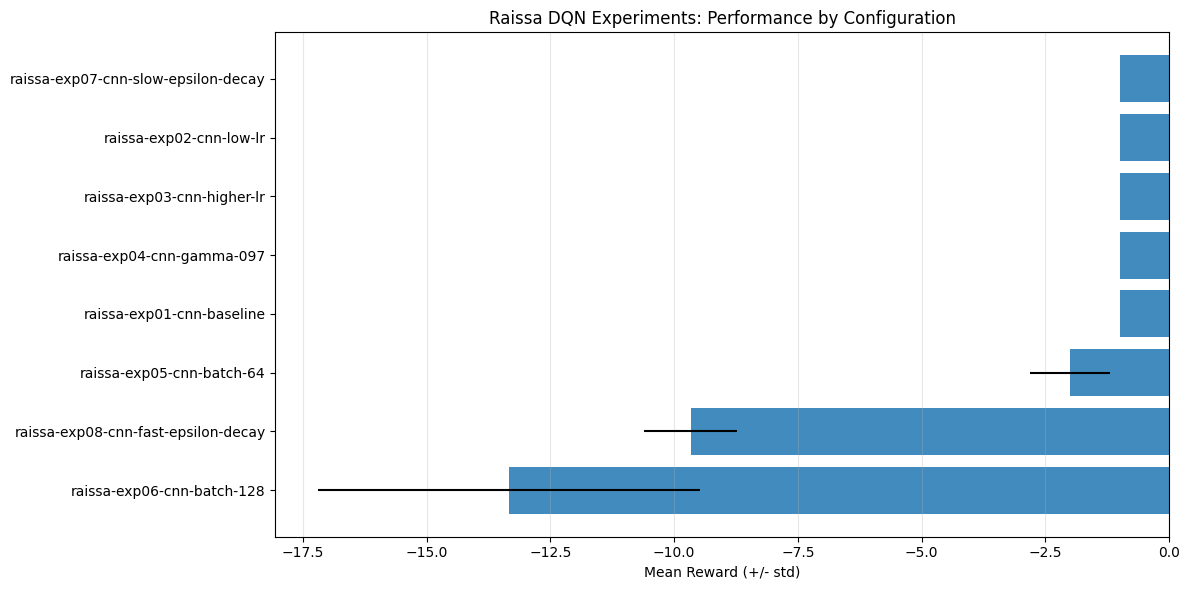

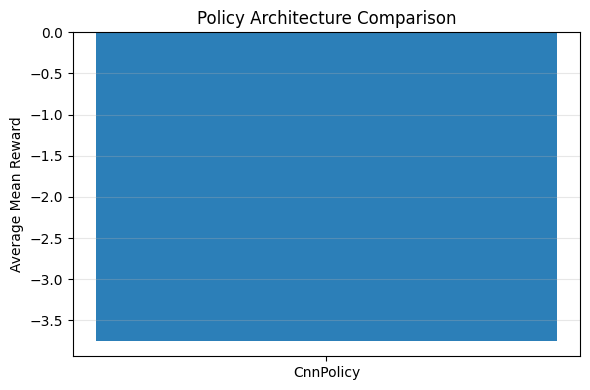

Average reward by policy:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,policy,mean_reward
0,CnnPolicy,-3.75


In [6]:
# Cell 6: Visual summaries (overall ranking + CNN vs MLP comparison)
if results_df.empty:
    print("results_df is empty. Run Cell 4 first.")
else:
    plot_df = results_df.sort_values("mean_reward", ascending=True).copy()

    plt.figure(figsize=(12, 6))
    bar_colors = ["#2c7fb8" if p == "CnnPolicy" else "#d95f0e" for p in plot_df["policy"]]
    plt.barh(plot_df["name"], plot_df["mean_reward"], xerr=plot_df["std_reward"], color=bar_colors, alpha=0.9)
    plt.xlabel("Mean Reward (+/- std)")
    plt.title("Raissa DQN Experiments: Performance by Configuration")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    summary = results_df.groupby("policy", as_index=False)["mean_reward"].mean()
    plt.figure(figsize=(6, 4))
    plt.bar(summary["policy"], summary["mean_reward"], color=["#2c7fb8", "#d95f0e"])
    plt.ylabel("Average Mean Reward")
    plt.title("Policy Architecture Comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Average reward by policy:")
    display(summary)

In [7]:
# Cell 7: Export artifacts to Google Drive + optional download links + optional headless gameplay video
if results_df.empty:
    print("results_df is empty. Run Cell 4 first.")
else:
    if BEST_MODEL_PATH.exists():
        print(f"Best model available: {BEST_MODEL_PATH}")
    else:
        print("Best model not found yet. Run Cell 4 first.")

    artifact_paths = [
        ASSIGNMENT_MODEL_PATH,
        BEST_MODEL_PATH,
        RESULTS_CSV,
        RESULTS_MD,
    ]

    print("\nLocal artifacts:")
    for p in artifact_paths:
        print(f" - {p} ({'OK' if p.exists() else 'MISSING'})")

    if DRIVE_MOUNTED and DRIVE_EXPORT_DIR is not None:
        for p in artifact_paths:
            if p.exists():
                dst = DRIVE_EXPORT_DIR / p.name
                shutil.copy(str(p), str(dst))
        print(f"\nCopied artifacts to Google Drive: {DRIVE_EXPORT_DIR}")

    if COLAB_FILES is not None:
        for p in artifact_paths:
            if p.exists():
                COLAB_FILES.download(str(p))
    else:
        print("Download links only work inside Colab.")

    # Optional: record a short headless video using the assignment model (CnnPolicy only).
    RECORD_VIDEO = False
    if RECORD_VIDEO and ASSIGNMENT_MODEL_PATH.exists():
        video_root = VIDEO_DIR / "playback"
        video_root.mkdir(parents=True, exist_ok=True)

        play_env = gym.make(ENV_ID, render_mode="rgb_array")
        play_env = RecordVideo(
            play_env,
            video_folder=str(video_root),
            episode_trigger=lambda episode_id: episode_id % 1 == 0,
            name_prefix="raissa_play",
        )

        model = DQN.load(str(ASSIGNMENT_MODEL_PATH))
        obs, _ = play_env.reset(seed=SEED)
        done = False
        ep_reward = 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = play_env.step(int(action))
            ep_reward += float(reward)
            done = terminated or truncated
        play_env.close()

        print(f"Recorded one gameplay episode. Reward: {ep_reward:.2f}")
        print(f"Video folder: {video_root}")

Best model available: results/raissa/models/best_dqn_tennis.zip

Local artifacts:
 - results/raissa/models/dqn_model.zip (OK)
 - results/raissa/models/best_dqn_tennis.zip (OK)
 - results/raissa/tables/raissa_hyperparameter_results.csv (OK)
 - results/raissa/tables/raissa_hyperparameter_results.md (OK)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8 · Load Results
This section rebuilds a clean results table from saved artifacts so you can rerun reporting cells without retraining.

In [8]:
# Rebuild a reporting dataframe from saved CSV (fallback to in-memory results_df).
results_csv_path = TABLE_DIR / "raissa_hyperparameter_results.csv"

if results_csv_path.exists():
    report_df = pd.read_csv(results_csv_path)
    print(f"Loaded saved results: {results_csv_path}")
elif "results_df" in globals() and not results_df.empty:
    report_df = results_df.copy()
    print("Using in-memory results_df (not yet saved to CSV).")
else:
    report_df = pd.DataFrame()
    print("No results found. Run Cell 4 and Cell 5 first.")

if not report_df.empty:
    # Standard column names for downstream reporting cells
    df = pd.DataFrame({
        "Exp": report_df["name"],
        "Policy": report_df["policy"],
        "lr": report_df["learning_rate"],
        "gamma": report_df["gamma"],
        "batch": report_df["batch_size"],
        "eps_start": report_df["exploration_initial_eps"],
        "eps_end": report_df["exploration_final_eps"],
        "eps_frac": report_df["exploration_fraction"],
        "mean_reward": report_df["mean_reward"],
        "std_reward": report_df["std_reward"],
        "train_min": report_df["train_minutes"],
    })
    df = df.sort_values("mean_reward", ascending=False).reset_index(drop=True)
    display(df)

Loaded saved results: results/raissa/tables/raissa_hyperparameter_results.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Exp,Policy,lr,gamma,batch,eps_start,eps_end,eps_frac,mean_reward,std_reward,train_min
0,raissa-exp01-cnn-baseline,CnnPolicy,0.00010,0.99,32,1.0,0.01,0.10,-1.000000,0.000000,6.004621
1,raissa-exp02-cnn-low-lr,CnnPolicy,0.00005,0.99,32,1.0,0.01,0.10,-1.000000,0.000000,5.902203
2,raissa-exp03-cnn-higher-lr,CnnPolicy,0.00025,0.99,32,1.0,0.01,0.10,-1.000000,0.000000,5.966845
3,raissa-exp04-cnn-gamma-097,CnnPolicy,0.00010,0.97,32,1.0,0.01,0.10,-1.000000,0.000000,5.969977
4,raissa-exp07-cnn-slow-epsilon-decay,CnnPolicy,0.00010,0.99,64,1.0,0.05,0.25,-1.000000,0.000000,6.201877
5,raissa-exp05-cnn-batch-64,CnnPolicy,0.00010,0.99,64,1.0,0.01,0.10,-2.000000,0.816497,6.300254
6,raissa-exp08-cnn-fast-epsilon-decay,CnnPolicy,0.00010,0.99,64,1.0,0.01,0.05,-9.666667,0.942809,6.319442
7,raissa-exp06-cnn-batch-128,CnnPolicy,0.00010,0.99,128,1.0,0.02,0.12,-13.333333,3.858612,7.718636


## 9 · Hyperparameter Table Exact Assignment Format


In [9]:
# Build assignment-format table from your experiment definitions and merge real rewards when available.
def _default_behavior(name: str, policy: str) -> str:
    if policy == "MlpPolicy":
        return f"[{name}] MLP ablation run. Usually weaker than CNN on pixel-based Atari due to reduced visual feature extraction."
    return f"[{name}] CNN run. Evaluate reward trend and stability against baseline to determine if this config helps or hurts."

assignment_rows = []
for exp_cfg in experiments:
    hp = exp_cfg["hp"]
    hset = (
        f"lr={hp['learning_rate']}, gamma={hp['gamma']}, batch={hp['batch_size']}, "
        f"epsilon_start={hp['exploration_initial_eps']}, epsilon_end={hp['exploration_final_eps']}, "
        f"epsilon_decay={hp['exploration_fraction']}"
    )
    assignment_rows.append({
        "Member Name": "Raissa",
        "Hyperparameter Set": hset,
        "Noted Behavior": _default_behavior(exp_cfg["name"], exp_cfg["policy"]),
        "Exp": exp_cfg["name"],
    })

assignment_df = pd.DataFrame(assignment_rows)

if "df" in globals() and not df.empty:
    reward_map = dict(zip(df["Exp"], zip(df["mean_reward"], df["std_reward"])))
    merged_behavior = []
    for _, row in assignment_df.iterrows():
        mr, sr = reward_map.get(row["Exp"], (None, None))
        if mr is None:
            merged_behavior.append(row["Noted Behavior"] + " | Mean Reward: not run")
        else:
            merged_behavior.append(row["Noted Behavior"] + f" | Mean Reward: {mr:.2f} +/- {sr:.2f}")
    assignment_df["Noted Behavior"] = merged_behavior

display(assignment_df[["Member Name", "Hyperparameter Set", "Noted Behavior"]])

assignment_table_path = TABLE_DIR / "raissa_assignment_table.csv"
assignment_df[["Member Name", "Hyperparameter Set", "Noted Behavior"]].to_csv(assignment_table_path, index=False)
print(f"Saved assignment-format table -> {assignment_table_path}")

,Member Name,Hyperparameter Set,Noted Behavior
0,Raissa,"lr=0.0001, gamma=0.99, batch=32, epsilon_start...",[raissa-exp01-cnn-baseline] CNN run. Evaluate ...
1,Raissa,"lr=5e-05, gamma=0.99, batch=32, epsilon_start=...",[raissa-exp02-cnn-low-lr] CNN run. Evaluate re...
2,Raissa,"lr=0.00025, gamma=0.99, batch=32, epsilon_star...",[raissa-exp03-cnn-higher-lr] CNN run. Evaluate...
3,Raissa,"lr=0.0001, gamma=0.97, batch=32, epsilon_start...",[raissa-exp04-cnn-gamma-097] CNN run. Evaluate...
4,Raissa,"lr=0.0001, gamma=0.99, batch=64, epsilon_start...",[raissa-exp05-cnn-batch-64] CNN run. Evaluate ...
5,Raissa,"lr=0.0001, gamma=0.99, batch=128, epsilon_star...",[raissa-exp06-cnn-batch-128] CNN run. Evaluate...
6,Raissa,"lr=0.0001, gamma=0.99, batch=64, epsilon_start...",[raissa-exp07-cnn-slow-epsilon-decay] CNN run....
7,Raissa,"lr=0.0001, gamma=0.99, batch=64, epsilon_start...",[raissa-exp08-cnn-fast-epsilon-decay] CNN run....
8,Raissa,"lr=0.0001, gamma=0.99, batch=64, epsilon_start...",[raissa-exp09-mlp-baseline-ram] MLP ablation r...
9,Raissa,"lr=0.0002, gamma=0.98, batch=128, epsilon_star...",[raissa-exp10-mlp-alt] MLP ablation run. Usual...


Saved assignment-format table -> results/raissa/tables/raissa_assignment_table.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 10 · Reward Comparison Chart

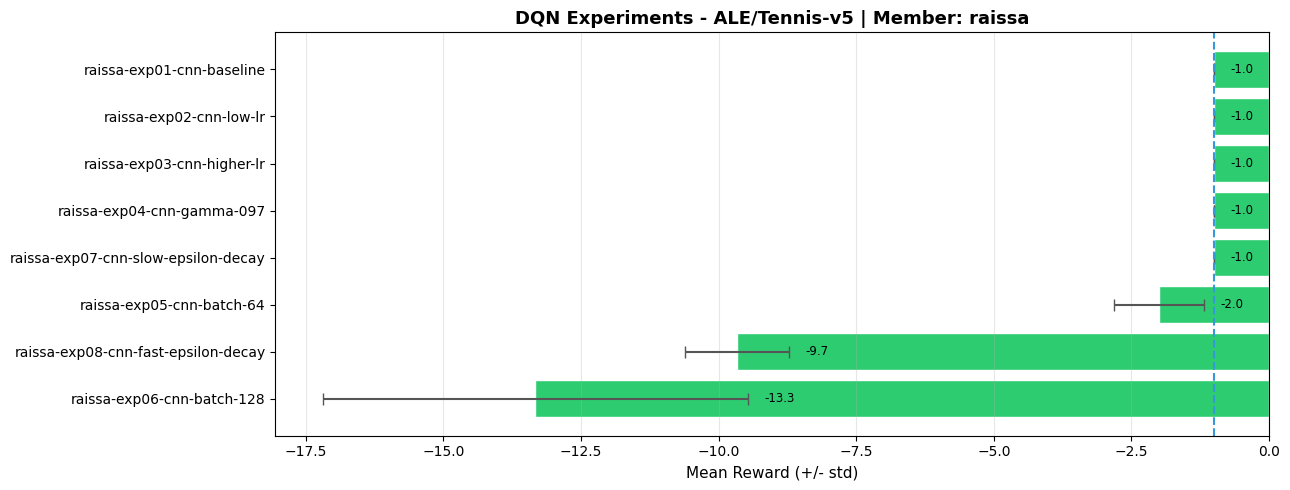

Saved -> results/raissa/tables/raissa_reward_comparison.png


In [10]:
if "df" in globals() and len(df) > 0:
    fig, ax = plt.subplots(figsize=(13, 5))
    colors = ["#2ecc71" if "Cnn" in p else "#e74c3c" for p in df["Policy"]]
    bars = ax.barh(
        df["Exp"],
        df["mean_reward"],
        xerr=df["std_reward"],
        color=colors,
        edgecolor="white",
        error_kw=dict(ecolor="#555", capsize=4, lw=1.5),
    )

    for bar, val, std in zip(bars, df["mean_reward"], df["std_reward"]):
        ax.text(
            bar.get_width() + abs(std) + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}",
            va="center",
            fontsize=8.5,
        )

    baseline_val = df[df["Exp"] == "raissa-exp01-cnn-baseline"]["mean_reward"].values
    if len(baseline_val):
        ax.axvline(baseline_val[0], color="#3498db", ls="--", lw=1.5, label="Baseline")

    ax.set_xlabel("Mean Reward (+/- std)", fontsize=11)
    ax.set_title(f"DQN Experiments - ALE/Tennis-v5 | Member: {MEMBER}", fontsize=13, fontweight="bold")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    reward_plot_path = TABLE_DIR / "raissa_reward_comparison.png"
    plt.savefig(reward_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {reward_plot_path}")
else:
    print("No results yet - run Cell 4 and Cell 8 first.")

## 11 · Training Curves (Reward over Time)

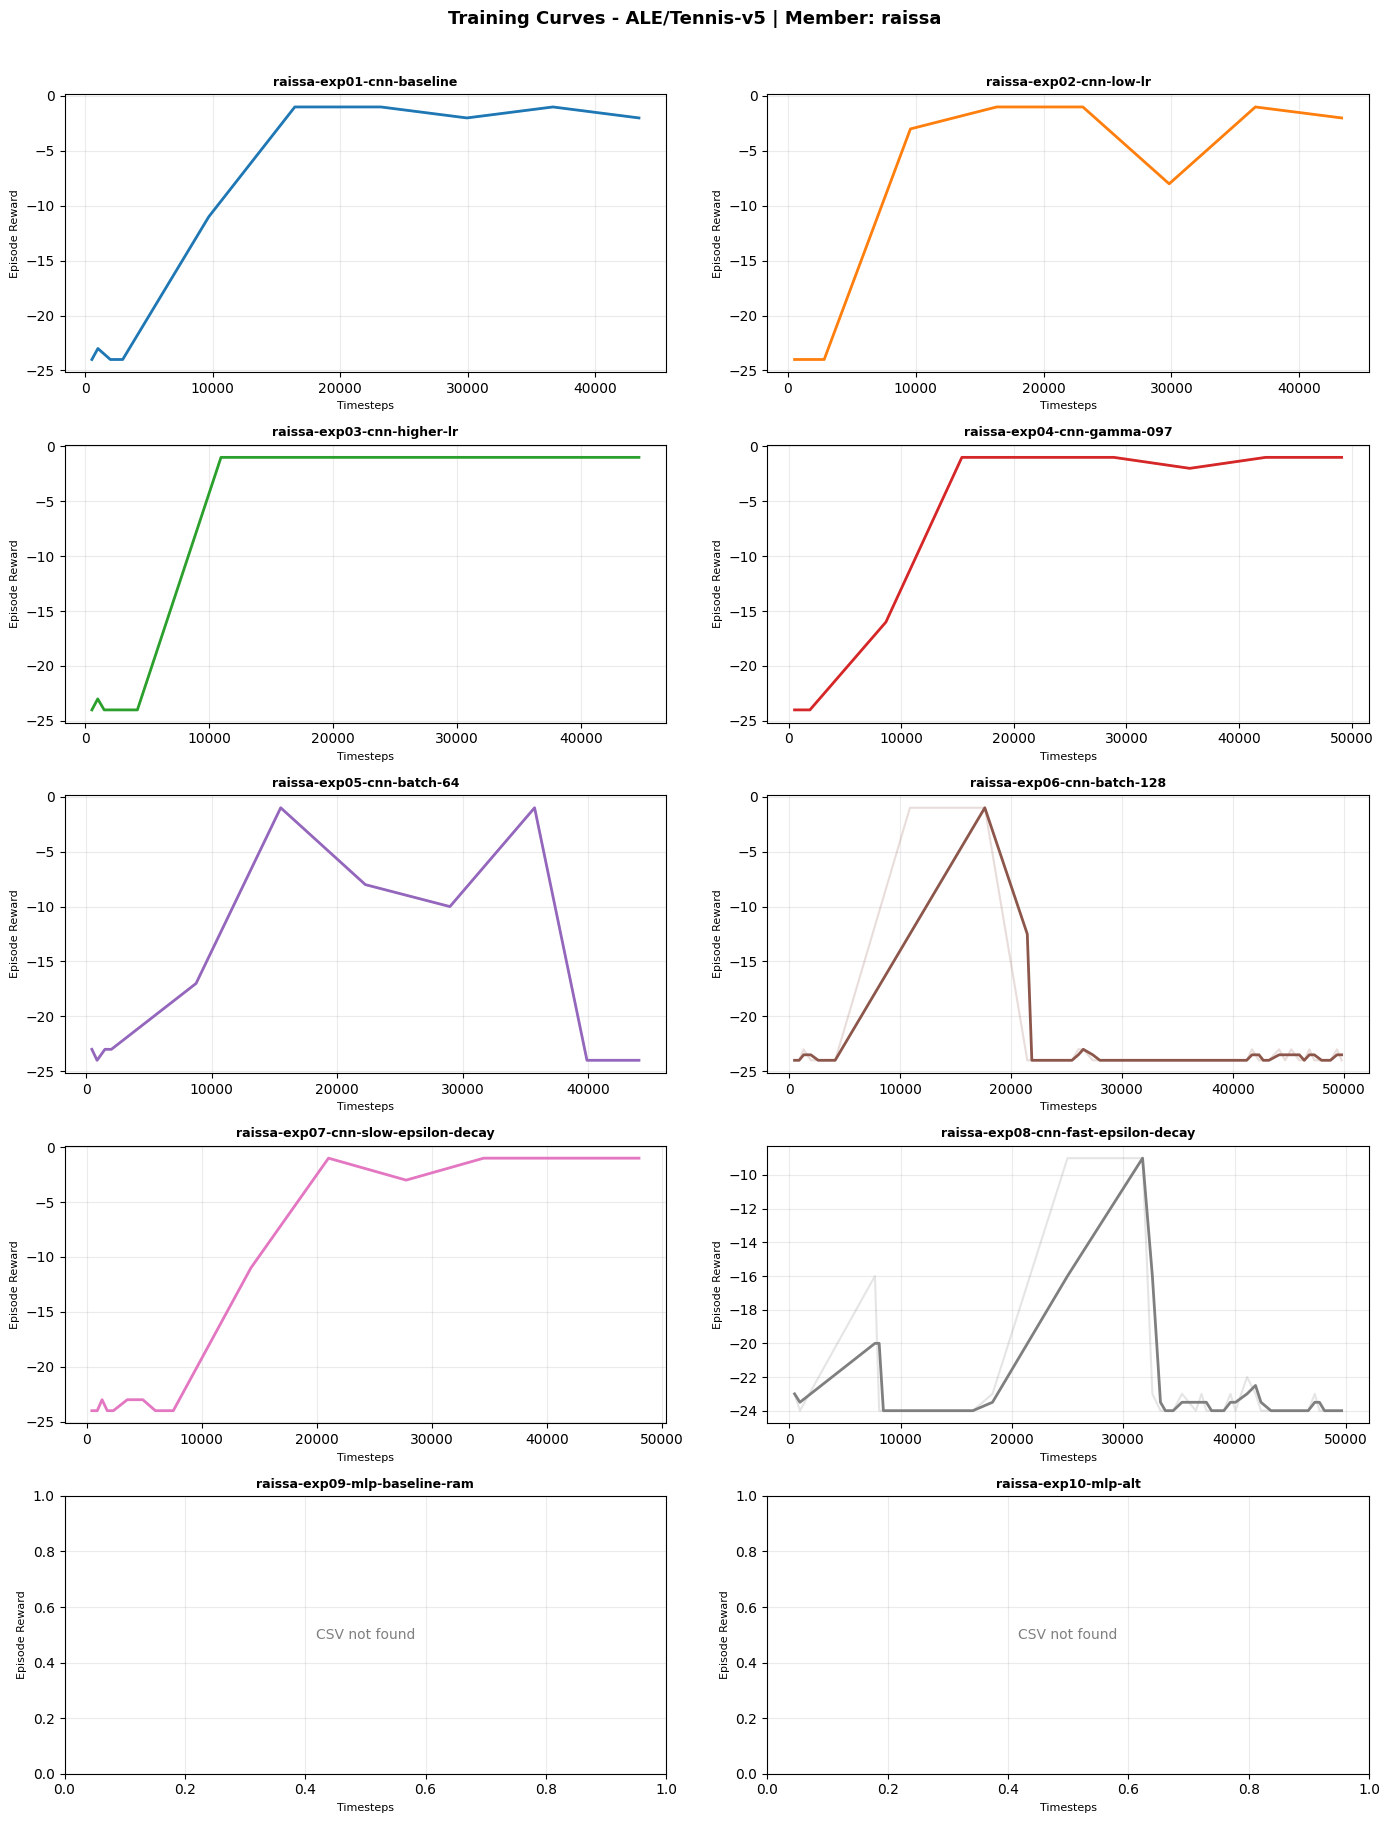

Saved -> results/raissa/tables/raissa_training_curves.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()
palette = plt.cm.tab10.colors

for i, cfg in enumerate(experiments):
    exp_name = cfg["name"]
    csv_path = LOG_DIR / f"{exp_name}_training_metrics.csv"
    ax = axes[i]

    if csv_path.exists():
        log_df = pd.read_csv(csv_path)
        if not log_df.empty:
            w = max(1, len(log_df) // 20)
            smooth = log_df["ep_reward"].rolling(w, min_periods=1).mean()
            ax.plot(log_df["timestep"], log_df["ep_reward"], alpha=0.2, color=palette[i % 10])
            ax.plot(log_df["timestep"], smooth, color=palette[i % 10], lw=2)
        else:
            ax.text(0.5, 0.5, "No episodes logged", ha="center", va="center", transform=ax.transAxes, color="gray")
    else:
        ax.text(0.5, 0.5, "CSV not found", ha="center", va="center", transform=ax.transAxes, color="gray")

    ax.set_title(exp_name, fontsize=9, fontweight="bold")
    ax.set_xlabel("Timesteps", fontsize=8)
    ax.set_ylabel("Episode Reward", fontsize=8)
    ax.grid(alpha=0.25)

plt.suptitle(f"Training Curves - ALE/Tennis-v5 | Member: {MEMBER}", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
curves_path = TABLE_DIR / "raissa_training_curves.png"
plt.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {curves_path}")

## 12 · Save Best Model as dqn_model.zip

In [12]:
if "df" in globals() and len(df) > 0:
    best_row = df.loc[df["mean_reward"].idxmax()]
    best_exp = best_row["Exp"]
    print(f"Best experiment: {best_exp}")
    print(f"Mean reward: {best_row['mean_reward']:.2f}")

    src = MODEL_DIR / f"{best_exp}.zip"
    alt = MODEL_DIR / "best_dqn_tennis.zip"
    target = MODEL_DIR / "dqn_model.zip"

    if src.exists():
        shutil.copy(str(src), str(target))
        print(f"Saved -> {target}")
    elif alt.exists():
        shutil.copy(str(alt), str(target))
        print(f"Saved fallback best -> {target}")
    else:
        print("[WARNING] Model zip not found. Run Cell 4 first.")
else:
    print("No results. Run Cell 4 and Cell 8 first.")

Best experiment: raissa-exp01-cnn-baseline
Mean reward: -1.00
Saved -> results/raissa/models/dqn_model.zip


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 13 · Key Insights Summary

In [13]:
if "df" in globals() and len(df) > 0:
    best = df.loc[df["mean_reward"].idxmax()]
    worst = df.loc[df["mean_reward"].idxmin()]
    cnn_mean = df[df["Policy"] == "CnnPolicy"]["mean_reward"].mean()
    mlp_mean = df[df["Policy"] == "MlpPolicy"]["mean_reward"].mean()

    best_exp = best["Exp"]
    best_mean = float(best["mean_reward"])
    best_std = float(best["std_reward"])
    best_lr = best["lr"]
    best_gamma = best["gamma"]
    best_batch = int(best["batch"])
    best_eps_start = best["eps_start"]
    best_eps_end = best["eps_end"]
    best_eps_frac = best["eps_frac"]

    worst_exp = worst["Exp"]
    worst_mean = float(worst["mean_reward"] )
    worst_std = float(worst["std_reward"])

    print("=" * 65)
    print(f"  KEY INSIGHTS - Member: {MEMBER}")
    print("=" * 65)
    print(f"\n1. BEST CONFIG: {best_exp}")
    print(f"   Mean reward : {best_mean:.2f} +/- {best_std:.2f}")
    print(f"   lr={best_lr}, gamma={best_gamma}, batch={best_batch}")
    print(f"   eps_start={best_eps_start}, eps_end={best_eps_end}, eps_frac={best_eps_frac}")

    print(f"\n2. WORST CONFIG: {worst_exp}")
    print(f"   Mean reward : {worst_mean:.2f} +/- {worst_std:.2f}")

    print("\n3. CNN vs MLP")
    print(f"   CNN mean reward : {cnn_mean:.2f}")
    print(f"   MLP mean reward : {mlp_mean:.2f}")
    winner = "CNN" if cnn_mean > mlp_mean else "MLP"
    print(f"   {winner} is better by {abs(cnn_mean - mlp_mean):.2f} points")

    print("\n4. Hyperparameter Sensitivity")
    print("   Compare runs by LR, gamma, batch size, and epsilon decay to explain performance trade-offs.")
    print("=" * 65)
else:
    print("No results. Run Cell 4 and Cell 8 first.")

  KEY INSIGHTS - Member: raissa

1. BEST CONFIG: raissa-exp01-cnn-baseline
   Mean reward : -1.00 +/- 0.00
   lr=0.0001, gamma=0.99, batch=32
   eps_start=1.0, eps_end=0.01, eps_frac=0.1

2. WORST CONFIG: raissa-exp06-cnn-batch-128
   Mean reward : -13.33 +/- 3.86

3. CNN vs MLP
   CNN mean reward : -3.75
   MLP mean reward : nan
   MLP is better by nan points

4. Hyperparameter Sensitivity
   Compare runs by LR, gamma, batch size, and epsilon decay to explain performance trade-offs.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
